## Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

plt.style.use("seaborn-v0_8-whitegrid")


In [2]:

vehicles = pd.read_csv("vehicles.csv")

print("Shape:", vehicles.shape)
vehicles.head()


Shape: (426880, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [3]:

vehicles = vehicles[(vehicles['price'] > 500) & (vehicles['price'] < 100000)]
vehicles = vehicles.dropna(subset=['price','year','odometer'])

vehicles = vehicles[(vehicles['year'] > 1980) & (vehicles['year'] <= 2026)]
vehicles = vehicles[(vehicles['odometer'] > 0) & (vehicles['odometer'] < 400000)]

vehicles['vehicle_age'] = 2026 - vehicles['year']
vehicles['log_price'] = np.log(vehicles['price'])


In [4]:

categorical_cols = ['manufacturer','fuel','transmission','title_status','state']

vehicles_model = vehicles[['log_price','vehicle_age','odometer'] + categorical_cols].dropna()

X = pd.get_dummies(
    vehicles_model.drop('log_price', axis=1),
    drop_first=True
)

y = vehicles_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [5]:

linear = LinearRegression()
linear.fit(X_train, y_train)

linear_pred = linear.predict(X_test)

linear_r2 = r2_score(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

print("Linear R2:", linear_r2)
print("Linear RMSE:", linear_rmse)


Linear R2: 0.6139139827977262
Linear RMSE: 0.5430109287542038


In [6]:

ridge_params = {'alpha':[0.01,0.1,1,10]}

ridge = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=3,
    scoring='r2'
)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print("Best alpha:", ridge.best_params_)
print("Ridge R2:", ridge_r2)
print("Ridge RMSE:", ridge_rmse)


C:\Users\chezk\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.53618e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Best alpha: {'alpha': 1}
Ridge R2: 0.613876757132142
Ridge RMSE: 0.5430371061539515


In [7]:

lasso_params = {'alpha':[0.0001,0.001,0.01]}

lasso = GridSearchCV(
    Lasso(max_iter=5000),
    lasso_params,
    cv=3,
    scoring='r2'
)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print("Best alpha:", lasso.best_params_)
print("Lasso R2:", lasso_r2)
print("Lasso RMSE:", lasso_rmse)


Best alpha: {'alpha': 0.0001}
Lasso R2: 0.612653122553944
Lasso RMSE: 0.5438968748771684


In [8]:

rf_params = {
    'n_estimators':[100,200],
    'max_depth':[10,15],
    'min_samples_split':[2,5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42,n_jobs=-1),
    rf_params,
    cv=3,
    scoring='r2'
)

rf_grid.fit(X_train, y_train)

rf_pred = rf_grid.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Best RF params:", rf_grid.best_params_)
print("Random Forest R2:", rf_r2)
print("Random Forest RMSE:", rf_rmse)


Best RF params: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest R2: 0.6906271709729568
Random Forest RMSE: 0.48607984998753007


In [9]:

xgb_params = {
    'n_estimators':[200],
    'max_depth':[3,5],
    'learning_rate':[0.05,0.1]
}

xgb_grid = GridSearchCV(
    XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ),
    xgb_params,
    cv=3,
    scoring='r2'
)

xgb_grid.fit(X_train, y_train)

xgb_pred = xgb_grid.predict(X_test)

xgb_r2 = r2_score(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("Best XGB params:", xgb_grid.best_params_)
print("XGBoost R2:", xgb_r2)
print("XGBoost RMSE:", xgb_rmse)


Best XGB params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
XGBoost R2: 0.6789444053435483
XGBoost RMSE: 0.4951726565632581


In [10]:

results = pd.DataFrame({
    "Model":[
        "Linear",
        "Ridge",
        "Lasso",
        "Random Forest",
        "XGBoost"
    ],
    "R2":[
        linear_r2,
        ridge_r2,
        lasso_r2,
        rf_r2,
        xgb_r2
    ],
    "RMSE":[
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        rf_rmse,
        xgb_rmse
    ]
})

results


,Model,R2,RMSE
0,Linear,0.613914,0.543011
1,Ridge,0.613877,0.543037
2,Lasso,0.612653,0.543897
3,Random Forest,0.690627,0.486080
4,XGBoost,0.678944,0.495173


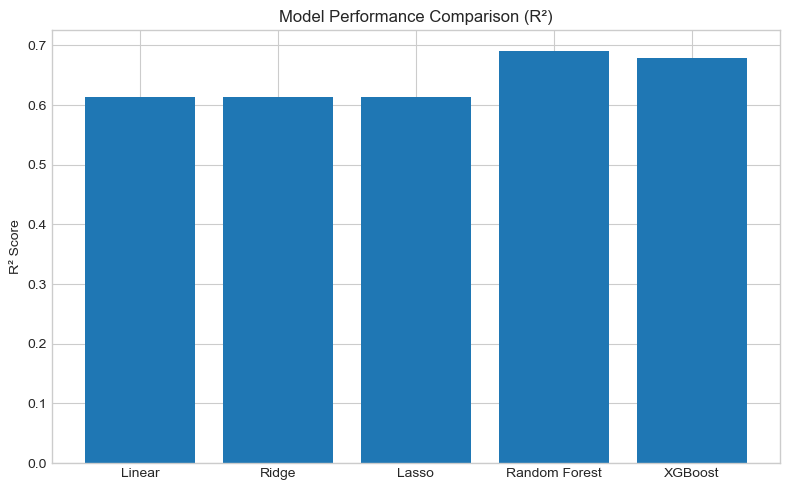

In [13]:

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(results["Model"], results["R2"])

ax.set_title("Model Performance Comparison (R²)")
ax.set_ylabel("R² Score")

plt.tight_layout()
plt.savefig("fig6_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


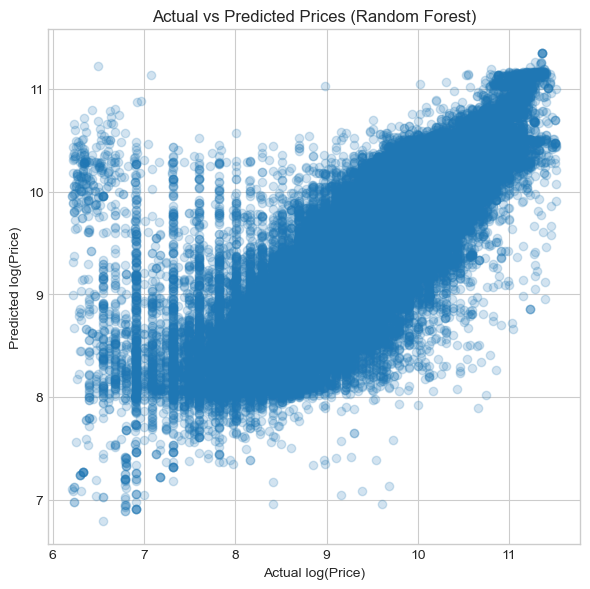

In [15]:
best_pred = rf_pred

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(y_test, best_pred, alpha=0.2)

ax.set_xlabel("Actual log(Price)")
ax.set_ylabel("Predicted log(Price)")
ax.set_title("Actual vs Predicted Prices (Random Forest)")

plt.tight_layout()
plt.savefig("fig7_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()


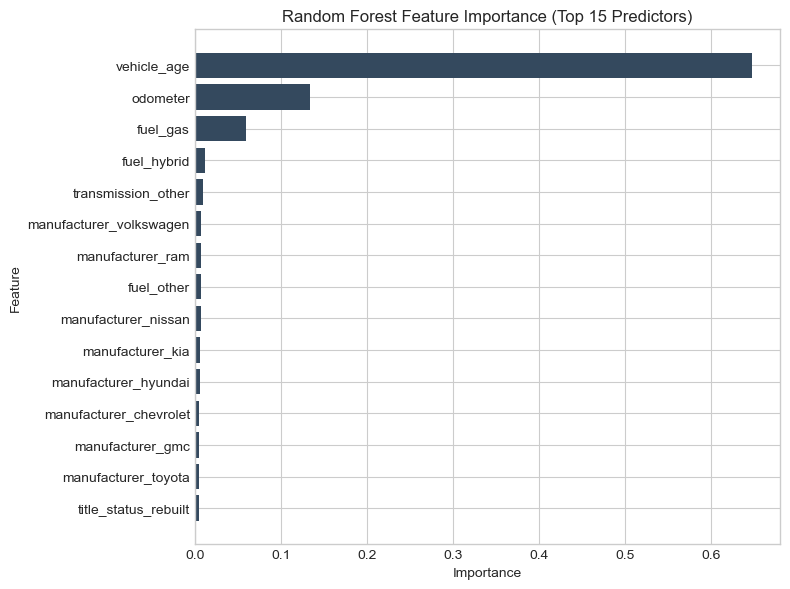

In [16]:
# Extract feature importances from the best Random Forest model
importances = pd.Series(
    rf_grid.best_estimator_.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Take the top 15 features
top_features = importances.head(15).sort_values()

fig, ax = plt.subplots(figsize=(8,6))

ax.barh(top_features.index, top_features.values, color="#34495E")

ax.set_title("Random Forest Feature Importance (Top 15 Predictors)")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig("fig5_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()